# 08. Event-aligned DMFC Encoding

Goal:
- Test whether residual-aligned DMFC activity is aligned to occlusion onset or final response timing.
- Compare:
  neural_t ~ y_det
  neural_t ~ y_det + paddle_residual
- Run shuffle and cluster controls in event-aligned time.

Interpretation:
- Occ-aligned effect: prediction / occlusion-period action-relevant estimate
- Final-aligned effect: response / endpoint-related activity

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in [PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

NEURAL_NPZ_PATH = INTERIM_DIR / "mahler_neural_ctu.npz"
BEHAVIOR_PATH = PROCESSED_DIR / "final_behavior_model_predictions_mahler.csv"

print("NEURAL_NPZ exists:", NEURAL_NPZ_PATH.exists())
print("BEHAVIOR_PATH exists:", BEHAVIOR_PATH.exists())

NEURAL_NPZ exists: True
BEHAVIOR_PATH exists: True


In [2]:
neural_npz = np.load(NEURAL_NPZ_PATH)
neural_ctu = neural_npz["neural_ctu"]

beh = pd.read_csv(BEHAVIOR_PATH)

print("neural_ctu shape:", neural_ctu.shape)
print("beh shape:", beh.shape)

# neural_ctu = condition × time × unit
n_cond, n_time, n_units = neural_ctu.shape

display(beh.head())

neural_ctu shape: (79, 100, 100)
beh shape: (79, 58)


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582,-0.271351,1.512199,-0.387616,1.343921,-0.820229,1.444340,-0.717167,1.547092,0.568326,-0.612109,1.521794,1.463708,-0.387616,0.759767,-0.230727,0.718746,-0.069906,0.948261
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716,-5.085588,1.567046,-4.704735,1.356974,-2.815561,1.633471,-5.308730,1.527418,0.290777,-4.955276,1.517295,1.426141,-4.704735,0.635699,-4.839890,0.630025,-5.188814,0.958497
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953,-6.007187,1.567046,-5.497139,1.356974,-4.740851,1.633471,-5.830621,1.696721,0.793983,-5.694956,1.523911,1.454085,-5.497139,0.644570,-5.584061,0.638817,-6.045057,1.039976
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918,-9.952948,1.404889,-8.925939,1.239052,-8.834230,1.607278,-9.607169,1.339460,0.156179,-8.132695,1.327884,0.824287,-8.925939,0.627907,-8.336010,0.591463,-9.230822,0.537432
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943,5.580770,1.512199,4.717728,1.343921,3.706159,1.444340,5.451764,1.547547,0.569565,4.894367,1.589112,1.726305,4.717728,0.833022,4.717494,0.788046,5.528507,0.888707


In [3]:
needed_cols = [
    "condition_i",
    "y_det",
    "y_paddle",
    "occ_idx",
    "final_idx",
    "y_occ",
    "vy_occ",
    "n_steps",
    "abs_vy_occ",
    "mc_mean_M6",
    "mc_std_M6",
    "sigma_M6_mc_mean_task_uncertainty",
]

needed_cols = [c for c in needed_cols if c in beh.columns]

cond_df = (
    beh[needed_cols]
    .drop_duplicates("condition_i")
    .sort_values("condition_i")
    .reset_index(drop=True)
)

assert cond_df["condition_i"].nunique() == n_cond
assert set(cond_df["condition_i"].astype(int)) == set(range(n_cond))

display(cond_df.head())
display(cond_df[["occ_idx", "final_idx", "n_steps"]].describe())

,condition_i,y_det,y_paddle,occ_idx,final_idx,y_occ,vy_occ,n_steps,abs_vy_occ,mc_mean_M6,mc_std_M6,sigma_M6_mc_mean_task_uncertainty
0,0,-0.271351,-0.688933,41,56,-2.787992,0.167776,15,0.167776,-0.069906,0.948261,0.718746
1,1,-5.085588,-3.723874,41,56,-8.066386,0.198720,15,0.198720,-5.188814,0.958497,0.630025
2,2,-6.007187,-5.745208,41,56,-2.995164,-0.200802,15,0.200802,-6.045057,1.039976,0.638817
3,3,-9.952948,-7.246475,36,49,-4.450462,-0.423268,13,0.423268,-9.230822,0.537432,0.591463
4,4,5.580770,5.144827,42,58,1.952503,0.226767,16,0.226767,5.528507,0.888707,0.788046


,occ_idx,final_idx,n_steps
count,79.000000,79.000000,79.000000
mean,30.822785,49.329114,18.506329
std,6.726830,10.618950,5.843852
min,19.000000,34.000000,13.000000
25%,24.500000,41.500000,15.000000
50%,31.000000,48.000000,16.000000
75%,37.000000,55.000000,19.000000
max,42.000000,76.000000,35.000000


In [4]:
valid = np.isfinite(cond_df["y_det"]) & np.isfinite(cond_df["y_paddle"])

coef = np.polyfit(
    cond_df.loc[valid, "y_det"],
    cond_df.loc[valid, "y_paddle"],
    deg=1,
)

gain_global = coef[0]
intercept_global = coef[1]

cond_df["y_paddle_pred_from_y_det"] = (
    gain_global * cond_df["y_det"] + intercept_global
)

cond_df["paddle_residual_from_y_det"] = (
    cond_df["y_paddle"] - cond_df["y_paddle_pred_from_y_det"]
)

print("global gain:", gain_global)
print("global intercept:", intercept_global)

display(
    cond_df[[
        "condition_i",
        "y_det",
        "y_paddle",
        "y_paddle_pred_from_y_det",
        "paddle_residual_from_y_det",
        "occ_idx",
        "final_idx",
    ]].head()
)

global gain: 0.8736645456633193
global intercept: -0.21198693774335028


,condition_i,y_det,y_paddle,y_paddle_pred_from_y_det,paddle_residual_from_y_det,occ_idx,final_idx
0,0,-0.271351,-0.688933,-0.449056,-0.239876,41,56
1,1,-5.085588,-3.723874,-4.655085,0.931211,41,56
2,2,-6.007187,-5.745208,-5.460253,-0.284955,41,56
3,3,-9.952948,-7.246475,-8.907524,1.661049,36,49
4,4,5.580770,5.144827,4.663734,0.481093,42,58


In [5]:
def make_kfold_indices(n, n_splits=5, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, n_splits)

    splits = []
    for i in range(n_splits):
        test_idx = folds[i]
        train_idx = np.setdiff1d(idx, test_idx)
        splits.append((train_idx, test_idx))

    return splits


def standardize_train_test(X_train, X_test, eps=1e-8):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)

    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)
    std = np.where(std < eps, 1.0, std)

    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std

    X_train_z = np.where(np.isfinite(X_train_z), X_train_z, 0.0)
    X_test_z = np.where(np.isfinite(X_test_z), X_test_z, 0.0)

    return X_train_z, X_test_z


def add_intercept(X):
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(len(X)), X])


def fit_ridge(X, Y, alpha=1.0):
    I = np.eye(X.shape[1])
    return np.linalg.solve(X.T @ X + alpha * I, X.T @ Y)


def score_population_r2(Y_true, Y_pred):
    mask = np.isfinite(Y_true)

    if mask.sum() == 0:
        return np.nan, np.nan, np.nan

    residual = Y_true[mask] - Y_pred[mask]
    sse = np.sum(residual ** 2)
    sst = np.sum(Y_true[mask] ** 2)

    r2 = 1.0 - sse / sst if sst > 0 else np.nan

    return r2, sse, sst

In [6]:
def extract_event_aligned_Y(
    neural_ctu,
    cond_df,
    align_col,
    rel_time,
):
    """
    Extract condition × unit neural matrix at event-aligned time.

    absolute_time_i = cond_df[align_col]_i + rel_time

    Returns:
        valid_cond_df: rows whose aligned time is within neural time range
        Y: condition_valid × unit
        abs_times: absolute time indices
    """
    event_idx = cond_df[align_col].to_numpy(dtype=float)
    abs_times = event_idx + rel_time

    valid = (
        np.isfinite(abs_times) &
        (abs_times >= 0) &
        (abs_times < neural_ctu.shape[1])
    )

    valid_cond_df = cond_df.loc[valid].copy().reset_index(drop=True)
    abs_times_valid = abs_times[valid].astype(int)

    cond_indices = valid_cond_df["condition_i"].to_numpy(dtype=int)

    Y = neural_ctu[cond_indices, abs_times_valid, :]

    return valid_cond_df, Y, abs_times_valid

In [7]:
def evaluate_event_aligned_encoding(
    neural_ctu,
    cond_df,
    align_col,
    rel_time,
    features,
    n_splits=5,
    seed=42,
    alpha=1.0,
    min_unit_finite=0.2,
):
    valid_cond_df, Y_raw, abs_times = extract_event_aligned_Y(
        neural_ctu=neural_ctu,
        cond_df=cond_df,
        align_col=align_col,
        rel_time=rel_time,
    )

    X_raw = valid_cond_df[features].to_numpy(dtype=float)

    # Unit filtering
    finite_ratio = np.isfinite(Y_raw).mean(axis=0)
    unit_std = np.nanstd(Y_raw, axis=0)

    keep_units = (
        (finite_ratio >= min_unit_finite) &
        np.isfinite(unit_std) &
        (unit_std > 1e-8)
    )

    if keep_units.sum() < 3:
        keep_units = (
            (finite_ratio >= 0.05) &
            np.isfinite(unit_std) &
            (unit_std > 1e-8)
        )

    Y_raw = Y_raw[:, keep_units]

    # Valid rows
    valid_x = np.isfinite(X_raw).any(axis=1)
    X_raw = X_raw[valid_x]
    Y_raw = Y_raw[valid_x]
    valid_cond_df = valid_cond_df.loc[valid_x].reset_index(drop=True)

    if len(valid_cond_df) < n_splits:
        return pd.DataFrame(), np.nan, len(valid_cond_df), int(keep_units.sum())

    splits = make_kfold_indices(len(valid_cond_df), n_splits=n_splits, seed=seed)

    all_sse = 0.0
    all_sst = 0.0

    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]

        Y_train_raw = Y_raw[train_idx]
        Y_test_raw = Y_raw[test_idx]

        X_train_z, X_test_z = standardize_train_test(X_train_raw, X_test_raw)
        X_train_design = add_intercept(X_train_z)
        X_test_design = add_intercept(X_test_z)

        y_mean = np.nanmean(Y_train_raw, axis=0, keepdims=True)
        y_std = np.nanstd(Y_train_raw, axis=0, keepdims=True)
        y_std = np.where(y_std < 1e-8, 1.0, y_std)

        Y_train_z = (Y_train_raw - y_mean) / y_std
        Y_test_z = (Y_test_raw - y_mean) / y_std

        Y_train_z_fit = np.where(np.isfinite(Y_train_z), Y_train_z, 0.0)

        beta = fit_ridge(X_train_design, Y_train_z_fit, alpha=alpha)
        Y_pred_z = X_test_design @ beta

        fold_r2, sse, sst = score_population_r2(Y_test_z, Y_pred_z)

        if np.isfinite(sse):
            all_sse += sse
            all_sst += sst

        fold_rows.append({
            "align_col": align_col,
            "rel_time": rel_time,
            "fold": fold,
            "features": ",".join(features),
            "n_conditions": len(valid_cond_df),
            "n_units": int(keep_units.sum()),
            "fold_population_r2": fold_r2,
            "sse": sse,
            "sst": sst,
        })

    pop_r2 = 1.0 - all_sse / all_sst if all_sst > 0 else np.nan

    return pd.DataFrame(fold_rows), pop_r2, len(valid_cond_df), int(keep_units.sum())

In [8]:
event_models = {
    "base_y_det": ["y_det"],
    "base_plus_paddle_residual": ["y_det", "paddle_residual_from_y_det"],
    "behavior_y_paddle": ["y_paddle"],
}

align_specs = {
    "occ": {
        "align_col": "occ_idx",
        "rel_times": np.arange(-20, 51),
    },
    "final": {
        "align_col": "final_idx",
        "rel_times": np.arange(-50, 41),
    },
}

event_rows = []
event_fold_rows = []

for align_name, spec in align_specs.items():
    align_col = spec["align_col"]

    for rel_time in spec["rel_times"]:
        for model_name, feats in event_models.items():
            cv_df, pop_r2, n_valid_cond, n_units_kept = evaluate_event_aligned_encoding(
                neural_ctu=neural_ctu,
                cond_df=cond_df,
                align_col=align_col,
                rel_time=int(rel_time),
                features=feats,
                n_splits=5,
                seed=42,
                alpha=1.0,
                min_unit_finite=0.2,
            )

            event_rows.append({
                "align_name": align_name,
                "align_col": align_col,
                "rel_time": int(rel_time),
                "model": model_name,
                "features": ",".join(feats),
                "population_r2": pop_r2,
                "n_valid_conditions": n_valid_cond,
                "n_units": n_units_kept,
            })

            if len(cv_df) > 0:
                cv_df["align_name"] = align_name
                cv_df["model"] = model_name
                event_fold_rows.append(cv_df)

event_encoding = pd.DataFrame(event_rows)

if len(event_fold_rows) > 0:
    event_folds = pd.concat(event_fold_rows, ignore_index=True)
else:
    event_folds = pd.DataFrame()

display(event_encoding.head())

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,align_name,align_col,rel_time,model,features,population_r2,n_valid_conditions,n_units
0,occ,occ_idx,-20,base_y_det,y_det,0.334362,78,29
1,occ,occ_idx,-20,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.352323,78,29
2,occ,occ_idx,-20,behavior_y_paddle,y_paddle,0.351292,78,29
3,occ,occ_idx,-19,base_y_det,y_det,0.289272,79,30
4,occ,occ_idx,-19,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.321994,79,30


In [9]:
event_wide = event_encoding.pivot_table(
    index=["align_name", "rel_time"],
    columns="model",
    values="population_r2",
).reset_index()

event_wide["delta_residual_over_y_det"] = (
    event_wide["base_plus_paddle_residual"] - event_wide["base_y_det"]
)

event_wide["delta_behavior_over_y_det"] = (
    event_wide["behavior_y_paddle"] - event_wide["base_y_det"]
)

display(event_wide.head())
display(event_wide.groupby("align_name")[[
    "base_y_det",
    "base_plus_paddle_residual",
    "behavior_y_paddle",
    "delta_residual_over_y_det",
]].describe())

model,align_name,rel_time,base_plus_paddle_residual,base_y_det,behavior_y_paddle,delta_residual_over_y_det,delta_behavior_over_y_det
0,final,-50,0.281524,0.279390,0.282037,0.002134,0.002647
1,final,-49,0.321059,0.321591,0.307483,-0.000532,-0.014108
2,final,-48,0.110999,0.151431,0.179538,-0.040432,0.028107
3,final,-47,0.323133,0.318370,0.347480,0.004762,0.029110
4,final,-46,0.237539,0.210512,0.234792,0.027026,0.024279


model      base_y_det                                                                       base_plus_paddle_residual                                                              \
                count      mean       std       min       25%       50%       75%       max                     count      mean       std       min       25%       50%       75%   
align_name                                                                                                                                                                          
final            91.0  0.283652  0.049822  0.151431  0.253354  0.282547  0.314028  0.393399                      91.0  0.298926  0.050602  0.110999  0.265417  0.306557  0.331800   
occ              71.0  0.287938  0.045642  0.164553  0.258804  0.289272  0.317858  0.375246                      71.0  0.303858  0.047434  0.170089  0.266114  0.308009  0.334747   

model                behavior_y_paddle                                                                       delta_residual_over_y_det                                          \
                 max             count      mean       std       min       25%       50%       75%       max                     count      mean       std       min       25%   
align_name                                                                                                                                                                       
final       0.406448              91.0  0.305957  0.047501  0.179538  0.277166  0.306307  0.338146  0.414184                      91.0  0.015274  0.019538 -0.040432  0.003580   
occ         0.405239              71.0  0.311026  0.044138  0.172108  0.279047  0.316248  0.343459  0.422018                      71.0  0.015920  0.021373 -0.035096  0.004045   

model                                     
                 50%       75%       max  
align_name                                
final       0.013086  0.026738  0.081367  
occ         0.014466  0.027387  0.069655

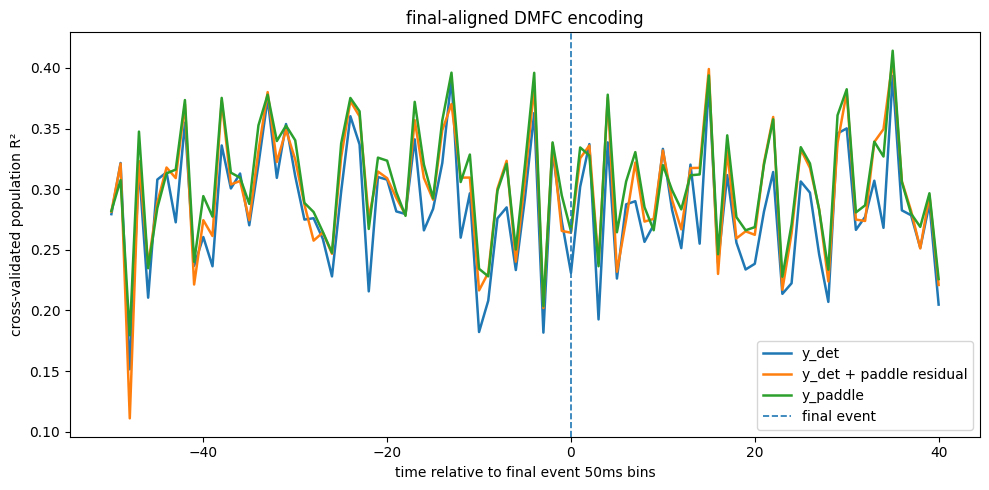

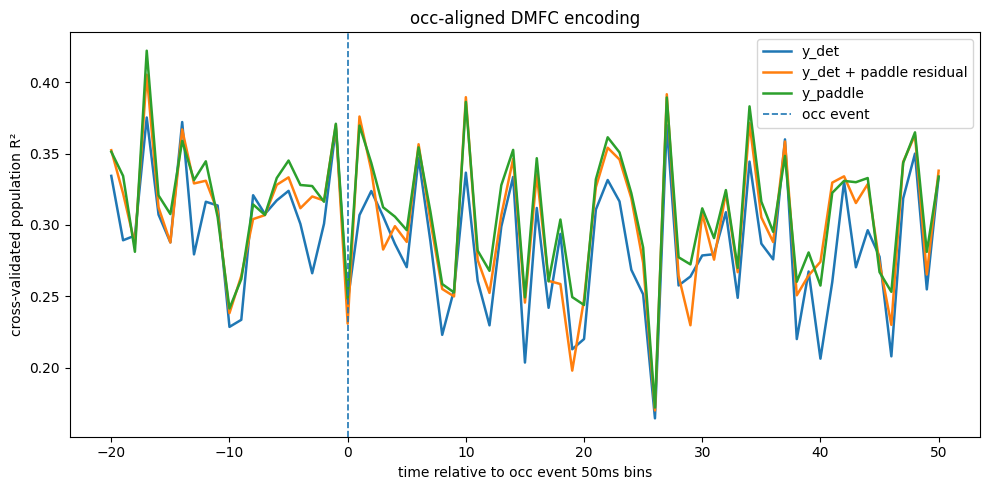

In [10]:
for align_name in event_wide["align_name"].unique():
    sub = event_wide[event_wide["align_name"] == align_name]

    plt.figure(figsize=(10, 5))

    plt.plot(
        sub["rel_time"],
        sub["base_y_det"],
        label="y_det",
        linewidth=1.8,
    )

    plt.plot(
        sub["rel_time"],
        sub["base_plus_paddle_residual"],
        label="y_det + paddle residual",
        linewidth=1.8,
    )

    plt.plot(
        sub["rel_time"],
        sub["behavior_y_paddle"],
        label="y_paddle",
        linewidth=1.8,
    )

    plt.axvline(0, linestyle="--", linewidth=1.2, label=f"{align_name} event")
    plt.xlabel(f"time relative to {align_name} event 50ms bins")
    plt.ylabel("cross-validated population R²")
    plt.title(f"{align_name}-aligned DMFC encoding")
    plt.legend()
    plt.tight_layout()
    plt.show()

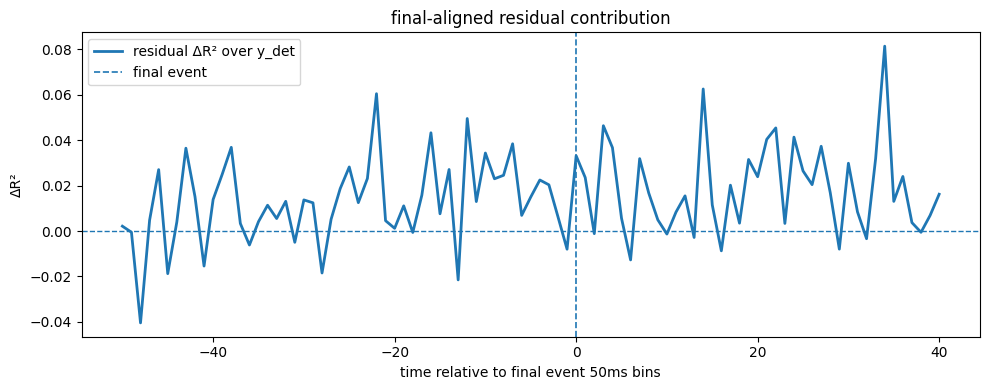

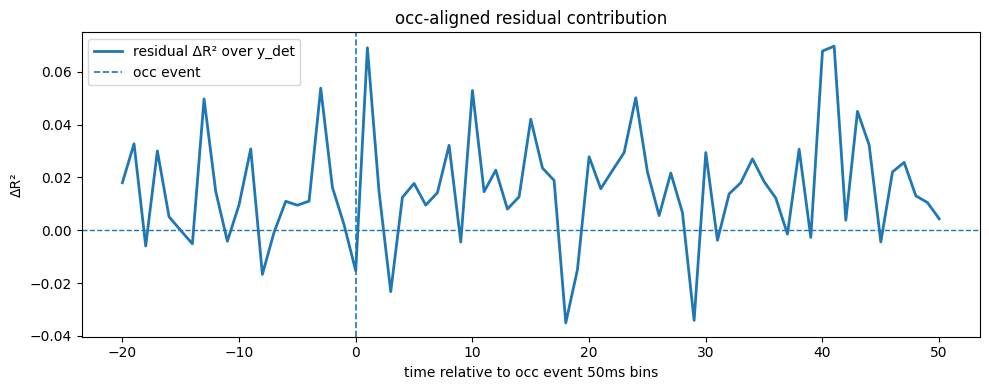

In [11]:
for align_name in event_wide["align_name"].unique():
    sub = event_wide[event_wide["align_name"] == align_name]

    plt.figure(figsize=(10, 4))

    plt.plot(
        sub["rel_time"],
        sub["delta_residual_over_y_det"],
        label="residual ΔR² over y_det",
        linewidth=2,
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1.2, label=f"{align_name} event")

    plt.xlabel(f"time relative to {align_name} event 50ms bins")
    plt.ylabel("ΔR²")
    plt.title(f"{align_name}-aligned residual contribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
def run_event_aligned_residual_shuffle(
    neural_ctu,
    cond_df,
    event_wide,
    align_specs,
    n_shuffle=100,
    seed=123,
):
    rng = np.random.default_rng(seed)

    shuffle_rows = []

    base_cond = cond_df[[
        "condition_i",
        "y_det",
        "paddle_residual_from_y_det",
        "occ_idx",
        "final_idx",
    ]].copy()

    for s in range(n_shuffle):
        shuf_cond = base_cond.copy()

        shuffled_resid = shuf_cond["paddle_residual_from_y_det"].values.copy()
        rng.shuffle(shuffled_resid)

        shuf_cond["paddle_residual_shuffled"] = shuffled_resid

        for align_name, spec in align_specs.items():
            align_col = spec["align_col"]

            for rel_time in spec["rel_times"]:
                _, r2_base, _, _ = evaluate_event_aligned_encoding(
                    neural_ctu=neural_ctu,
                    cond_df=shuf_cond,
                    align_col=align_col,
                    rel_time=int(rel_time),
                    features=["y_det"],
                    n_splits=5,
                    seed=42,
                    alpha=1.0,
                    min_unit_finite=0.2,
                )

                _, r2_shuf, _, _ = evaluate_event_aligned_encoding(
                    neural_ctu=neural_ctu,
                    cond_df=shuf_cond,
                    align_col=align_col,
                    rel_time=int(rel_time),
                    features=["y_det", "paddle_residual_shuffled"],
                    n_splits=5,
                    seed=42,
                    alpha=1.0,
                    min_unit_finite=0.2,
                )

                shuffle_rows.append({
                    "shuffle": s,
                    "align_name": align_name,
                    "rel_time": int(rel_time),
                    "base_r2": r2_base,
                    "shuffled_r2": r2_shuf,
                    "shuffled_delta_r2": r2_shuf - r2_base,
                })

    shuffle_df = pd.DataFrame(shuffle_rows)

    summary_rows = []

    for _, row in event_wide.iterrows():
        align_name = row["align_name"]
        rel_time = row["rel_time"]
        obs_delta = row["delta_residual_over_y_det"]

        shuf = shuffle_df.loc[
            (shuffle_df["align_name"] == align_name) &
            (shuffle_df["rel_time"] == rel_time),
            "shuffled_delta_r2",
        ].values

        if len(shuf) == 0 or not np.isfinite(obs_delta):
            continue

        p_empirical = (np.sum(shuf >= obs_delta) + 1) / (len(shuf) + 1)

        summary_rows.append({
            "align_name": align_name,
            "rel_time": rel_time,
            "observed_delta_r2": obs_delta,
            "shuffle_mean_delta": np.mean(shuf),
            "shuffle_std_delta": np.std(shuf, ddof=1),
            "shuffle_p95": np.percentile(shuf, 95),
            "shuffle_p99": np.percentile(shuf, 99),
            "empirical_p": p_empirical,
        })

    summary_df = pd.DataFrame(summary_rows)

    return summary_df, shuffle_df

In [13]:
event_shuffle_summary, event_shuffle_dist = run_event_aligned_residual_shuffle(
    neural_ctu=neural_ctu,
    cond_df=cond_df,
    event_wide=event_wide,
    align_specs=align_specs,
    n_shuffle=100,
    seed=123,
)

display(event_shuffle_summary.head())

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,align_name,rel_time,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p
0,final,-50,0.002134,-0.007720,0.022011,0.015158,0.028563,0.277228
1,final,-49,-0.000532,-0.012538,0.022532,0.018107,0.032881,0.306931
2,final,-48,-0.040432,-0.010041,0.031177,0.026930,0.047530,0.920792
3,final,-47,0.004762,-0.014010,0.021757,0.015792,0.030532,0.158416
4,final,-46,0.027026,-0.006235,0.023904,0.016726,0.037221,0.029703


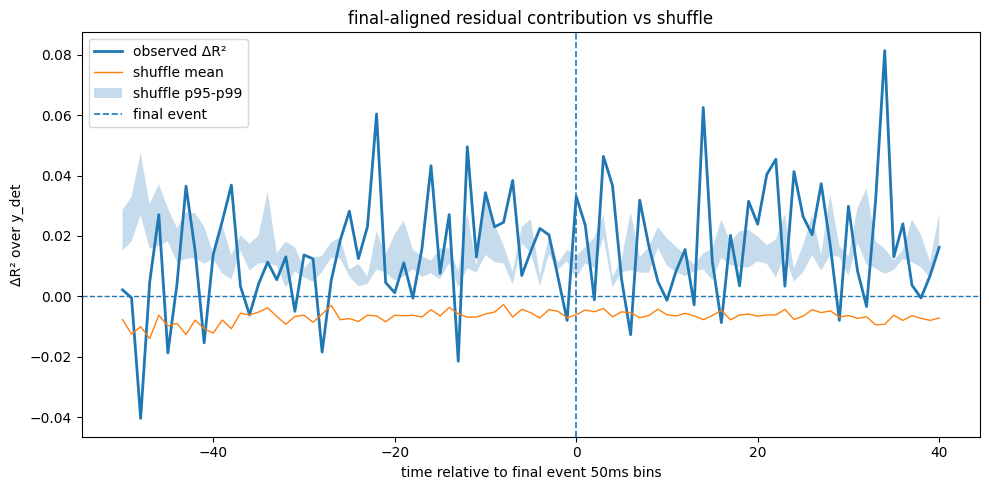

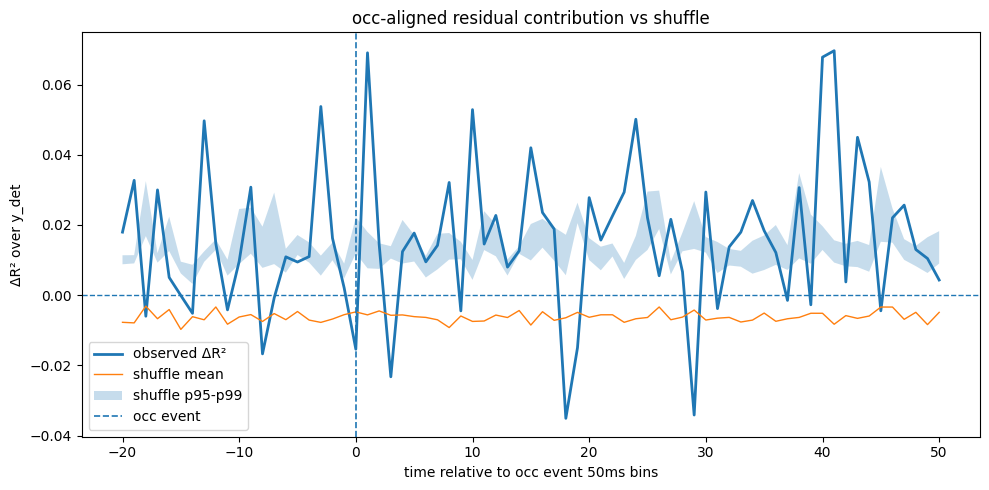

In [14]:
for align_name in event_shuffle_summary["align_name"].unique():
    sub = event_shuffle_summary[event_shuffle_summary["align_name"] == align_name]

    plt.figure(figsize=(10, 5))

    plt.plot(
        sub["rel_time"],
        sub["observed_delta_r2"],
        label="observed ΔR²",
        linewidth=2,
    )

    plt.plot(
        sub["rel_time"],
        sub["shuffle_mean_delta"],
        label="shuffle mean",
        linewidth=1,
    )

    plt.fill_between(
        sub["rel_time"],
        sub["shuffle_p95"],
        sub["shuffle_p99"],
        alpha=0.25,
        label="shuffle p95-p99",
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1.2, label=f"{align_name} event")

    plt.xlabel(f"time relative to {align_name} event 50ms bins")
    plt.ylabel("ΔR² over y_det")
    plt.title(f"{align_name}-aligned residual contribution vs shuffle")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
def find_clusters_above_threshold(values, threshold):
    values = np.asarray(values)
    above = values > threshold

    clusters = []
    start = None

    for i, is_above in enumerate(above):
        if is_above and start is None:
            start = i
        elif (not is_above) and start is not None:
            end = i - 1
            mass = np.sum(values[start:end+1] - threshold)
            clusters.append((start, end, mass))
            start = None

    if start is not None:
        end = len(values) - 1
        mass = np.sum(values[start:end+1] - threshold)
        clusters.append((start, end, mass))

    return clusters

In [ ]:
event_cluster_rows = []
event_max_cluster_rows = []

for align_name in event_shuffle_summary["align_name"].unique():
    obs_sub = event_shuffle_summary[event_shuffle_summary["align_name"] == align_name].sort_values("rel_time")
    shuf_sub = event_shuffle_dist[event_shuffle_dist["align_name"] == align_name].copy()

    # Global threshold per alignment
    threshold = np.percentile(shuf_sub["shuffled_delta_r2"].values, 95)

    observed_values = obs_sub["observed_delta_r2"].values
    rel_times = obs_sub["rel_time"].values

    obs_clusters = find_clusters_above_threshold(
        observed_values,
        threshold=threshold,
    )

    # Shuffle max cluster distribution
    max_rows = []

    for s, sub_s in shuf_sub.groupby("shuffle"):
        sub_s = sub_s.sort_values("rel_time")
        vals = sub_s["shuffled_delta_r2"].values

        clusters = find_clusters_above_threshold(vals, threshold=threshold)

        if len(clusters) == 0:
            max_mass = 0.0
            max_len = 0
        else:
            max_mass = max(c[2] for c in clusters)
            max_len = max(c[1] - c[0] + 1 for c in clusters)

        max_rows.append({
            "align_name": align_name,
            "shuffle": s,
            "threshold": threshold,
            "max_cluster_mass": max_mass,
            "max_cluster_len": max_len,
        })

    max_df = pd.DataFrame(max_rows)
    event_max_cluster_rows.append(max_df)

    for start_idx, end_idx, mass in obs_clusters:
        start_rel = rel_times[start_idx]
        end_rel = rel_times[end_idx]
        cluster_len = end_idx - start_idx + 1

        p = (
            np.sum(max_df["max_cluster_mass"].values >= mass) + 1
        ) / (len(max_df) + 1)

        event_cluster_rows.append({
            "align_name": align_name,
            "cluster_start_rel": int(start_rel),
            "cluster_end_rel": int(end_rel),
            "cluster_len": int(cluster_len),
            "cluster_mass": mass,
            "threshold": threshold,
            "cluster_p": p,
        })

event_cluster_summary = pd.DataFrame(event_cluster_rows).sort_values(
    ["align_name", "cluster_mass"],
    ascending=[True, False],
)

event_max_cluster_df = pd.concat(event_max_cluster_rows, ignore_index=True)

display(event_cluster_summary) # type: ignore

,align_name,cluster_start_rel,cluster_end_rel,cluster_len,cluster_mass,threshold,cluster_p
10,final,-12,-7,6,0.118340,0.010733,0.009901
21,final,33,36,4,0.107410,0.010733,0.009901
18,final,19,22,4,0.098171,0.010733,0.009901
6,final,-26,-22,5,0.089230,0.010733,0.009901
19,final,24,28,5,0.088687,0.010733,0.009901
13,final,3,4,2,0.061598,0.010733,0.029703
16,final,14,15,2,0.052539,0.010733,0.059406
2,final,-40,-38,3,0.043480,0.010733,0.069307
8,final,-17,-16,2,0.037582,0.010733,0.089109
12,final,0,1,2,0.035201,0.010733,0.108911


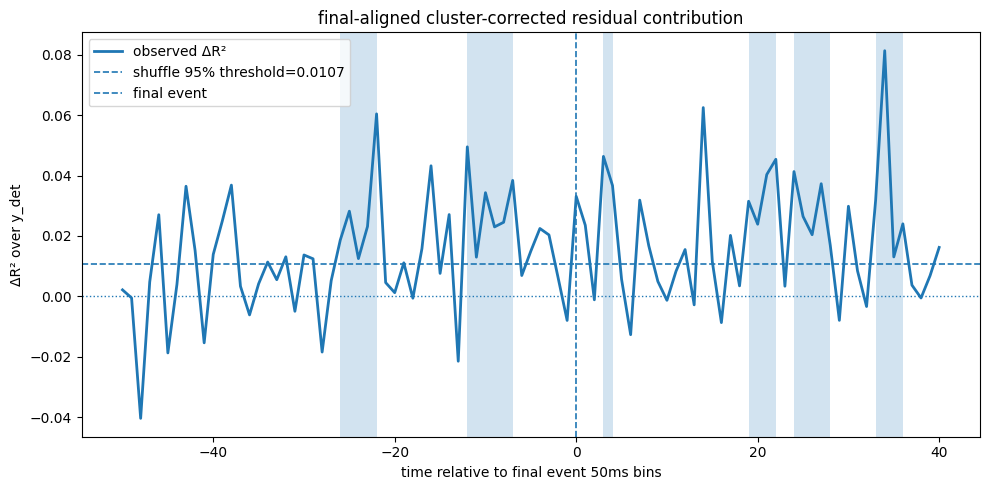

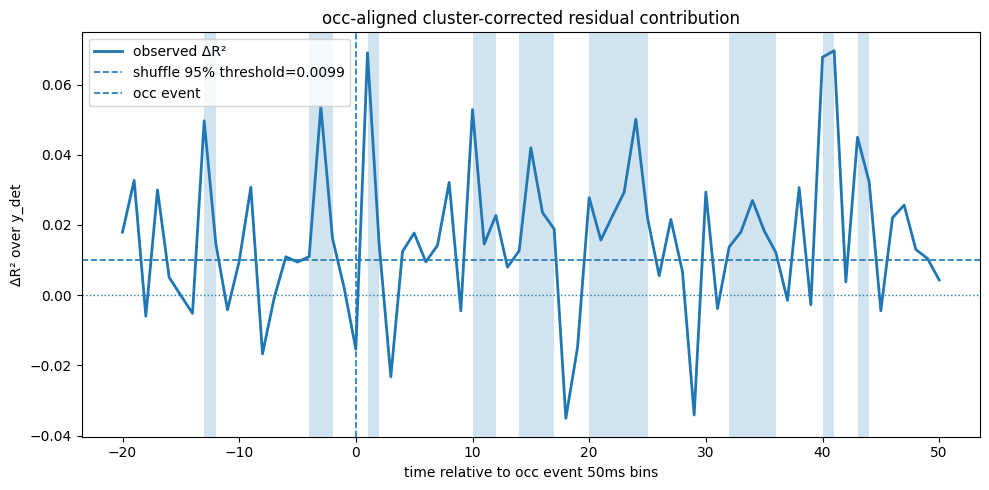

In [17]:
for align_name in event_shuffle_summary["align_name"].unique():
    sub = event_shuffle_summary[event_shuffle_summary["align_name"] == align_name].sort_values("rel_time")
    clusters = event_cluster_summary[
        (event_cluster_summary["align_name"] == align_name) &
        (event_cluster_summary["cluster_p"] < 0.05)
    ]

    threshold = clusters["threshold"].iloc[0] if len(clusters) > 0 else np.percentile(
        event_shuffle_dist[event_shuffle_dist["align_name"] == align_name]["shuffled_delta_r2"].values,
        95
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        sub["rel_time"],
        sub["observed_delta_r2"],
        label="observed ΔR²",
        linewidth=2,
    )

    plt.axhline(
        threshold,
        linestyle="--",
        linewidth=1.2,
        label=f"shuffle 95% threshold={threshold:.4f}",
    )

    plt.axhline(0, linestyle=":", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1.2, label=f"{align_name} event")

    for _, row in clusters.iterrows():
        plt.axvspan(
            row["cluster_start_rel"],
            row["cluster_end_rel"],
            alpha=0.2,
        )

    plt.xlabel(f"time relative to {align_name} event 50ms bins")
    plt.ylabel("ΔR² over y_det")
    plt.title(f"{align_name}-aligned cluster-corrected residual contribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
EVENT_ENCODING_PATH = PROCESSED_DIR / "dmfc_event_aligned_encoding_mahler.csv"
EVENT_FOLDS_PATH = PROCESSED_DIR / "dmfc_event_aligned_encoding_folds_mahler.csv"
EVENT_WIDE_PATH = PROCESSED_DIR / "dmfc_event_aligned_delta_r2_mahler.csv"
EVENT_SHUFFLE_SUMMARY_PATH = PROCESSED_DIR / "dmfc_event_aligned_residual_shuffle_summary_mahler.csv"
EVENT_SHUFFLE_DIST_PATH = PROCESSED_DIR / "dmfc_event_aligned_residual_shuffle_dist_mahler.csv"
EVENT_CLUSTER_PATH = PROCESSED_DIR / "dmfc_event_aligned_residual_cluster_summary_mahler.csv"
EVENT_MAX_CLUSTER_PATH = PROCESSED_DIR / "dmfc_event_aligned_residual_shuffle_max_cluster_mahler.csv"

event_encoding.to_csv(EVENT_ENCODING_PATH, index=False)
event_folds.to_csv(EVENT_FOLDS_PATH, index=False)
event_wide.to_csv(EVENT_WIDE_PATH, index=False)
event_shuffle_summary.to_csv(EVENT_SHUFFLE_SUMMARY_PATH, index=False)
event_shuffle_dist.to_csv(EVENT_SHUFFLE_DIST_PATH, index=False)
event_cluster_summary.to_csv(EVENT_CLUSTER_PATH, index=False)
event_max_cluster_df.to_csv(EVENT_MAX_CLUSTER_PATH, index=False)

print("Saved:", EVENT_ENCODING_PATH)
print("Saved:", EVENT_FOLDS_PATH)
print("Saved:", EVENT_WIDE_PATH)
print("Saved:", EVENT_SHUFFLE_SUMMARY_PATH)
print("Saved:", EVENT_SHUFFLE_DIST_PATH)
print("Saved:", EVENT_CLUSTER_PATH)
print("Saved:", EVENT_MAX_CLUSTER_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_encoding_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_encoding_folds_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_delta_r2_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_residual_shuffle_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_residual_shuffle_dist_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_residual_cluster_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_residual_shuffle_max_cluster_mahler.csv
